# classify_shape() 임계값 실측 재조정

`MUG_HEIGHT_TO_DIAMETER_MAX`(1.5), `STRAIGHT_BOTTOM_TOP_RATIO_MIN`(0.95), `STEP_JUMP_RATIO_THRESHOLD`(0.4)는 전부 처음엔 감으로 정한 값이었다. 이제 `data/raw2`(445장, 폴더 라벨 기준)와 Mask R-CNN의 비교적 깨끗한 마스크가 있으니, 실제 특징값 분포를 보고 다시 잡는다.

**방법**: 각 갈림길을 이진분류 문제로 놓고(예: `height_diameter_ratio <= t` → mug), 정확도를 최대화하는 임계값 `t`를 후보 중에서 탐색한다.

In [1]:
import sys, os, glob, statistics

sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from rule_based.shape_classifier import classify_shape, get_mask
from deep_learning.dl1_maskrcnn import load_model, get_mask_maskrcnn

DATA_DIR = os.path.join("..", "data", "raw2")
CLASSES = ["straight", "taper_smooth", "taper_step", "mug"]


def imread_unicode(path):
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


model, device = load_model()
print("device:", device)

device: cuda


## 1. `data/raw2` 전체에 Mask R-CNN 마스크로 특징값 수집

Mask R-CNN 마스크를 기준으로 삼는다 — 룰베이스보다 노이즈가 적어서(`maskrcnn_vs_rule_based.ipynb`: 85% vs 75%) 임계값을 잡는 기준으로 더 신뢰할 만하다.

In [2]:
rows = []
detect_fail = 0
for cls in CLASSES:
    files = sorted(glob.glob(os.path.join(DATA_DIR, cls, "*.jpg")))
    for path in files:
        image = imread_unicode(path)
        mask = get_mask_maskrcnn(image, model, device)
        if mask is None or not mask.any():
            detect_fail += 1
            continue
        result = classify_shape(mask)
        rows.append({"cls": cls, **result})

print(f"특징값 수집 완료: {len(rows)}장 (검출 실패로 제외: {detect_fail}장)")

for cls in CLASSES:
    vals = [r["height_diameter_ratio"] for r in rows if r["cls"] == cls]
    print(f"h/d {cls:14s} median={statistics.median(vals):.2f}  min={min(vals):.2f}  max={max(vals):.2f}")

특징값 수집 완료: 426장 (검출 실패로 제외: 19장)
h/d straight       median=2.90  min=0.24  max=5.80
h/d taper_smooth   median=1.85  min=0.99  max=2.66
h/d taper_step     median=1.83  min=0.85  max=2.72
h/d mug            median=1.19  min=0.42  max=2.41


## 2. 분포 시각화

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_4148\1059319723.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(hd_by_cls, labels=CLASSES)
C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_4148\1059319723.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(bt_by_cls, labels=["straight", "taper_smooth", "taper_step"])
C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_4148\1059319723.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(sr_by_cls, labels=["taper_smooth", "taper_step"])


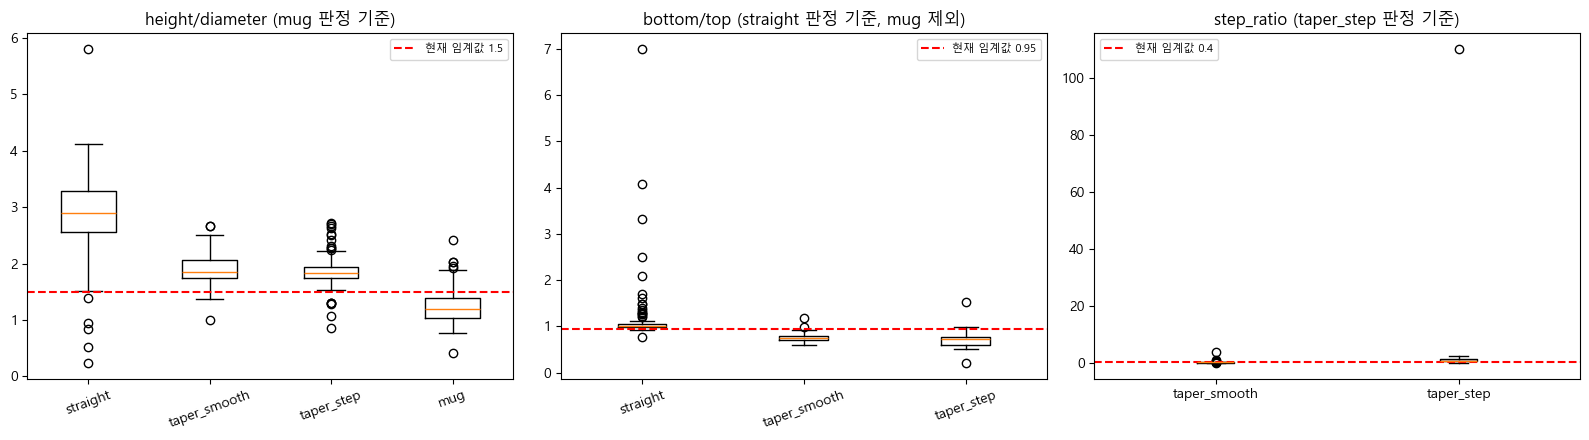

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

hd_by_cls = [[r["height_diameter_ratio"] for r in rows if r["cls"] == c] for c in CLASSES]
axes[0].boxplot(hd_by_cls, labels=CLASSES)
axes[0].axhline(1.5, color="red", linestyle="--", label="현재 임계값 1.5")
axes[0].set_title("height/diameter (mug 판정 기준)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=20)

non_mug = [r for r in rows if r["cls"] != "mug"]
bt_by_cls = [[r["bottom_top_ratio"] for r in non_mug if r["cls"] == c] for c in ("straight", "taper_smooth", "taper_step")]
axes[1].boxplot(bt_by_cls, labels=["straight", "taper_smooth", "taper_step"])
axes[1].axhline(0.95, color="red", linestyle="--", label="현재 임계값 0.95")
axes[1].set_title("bottom/top (straight 판정 기준, mug 제외)")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=20)

tapers = [r for r in rows if r["cls"] in ("taper_smooth", "taper_step")]
sr_by_cls = [[r["step_ratio"] for r in tapers if r["cls"] == c] for c in ("taper_smooth", "taper_step")]
axes[2].boxplot(sr_by_cls, labels=["taper_smooth", "taper_step"])
axes[2].axhline(0.4, color="red", linestyle="--", label="현재 임계값 0.4")
axes[2].set_title("step_ratio (taper_step 판정 기준)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. 최적 임계값 탐색

각 갈림길을 이진분류로 놓고, 후보 임계값(정렬된 값들의 중간점) 중 정확도를 최대화하는 지점을 고른다.

In [4]:
def best_threshold(values, is_positive, direction):
    """direction='le': value<=t를 양성으로 예측 / 'ge': value>=t를 양성으로 예측."""
    candidates = sorted(set(values))
    mids = [(candidates[i] + candidates[i + 1]) / 2 for i in range(len(candidates) - 1)]
    best_t, best_acc = None, -1
    for t in mids:
        pred = [(v <= t) if direction == "le" else (v >= t) for v in values]
        acc = sum(p == g for p, g in zip(pred, is_positive)) / len(is_positive)
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_t, best_acc


hd = [r["height_diameter_ratio"] for r in rows]
is_mug = [r["cls"] == "mug" for r in rows]
t_mug, acc_mug = best_threshold(hd, is_mug, "le")
print(f"MUG_HEIGHT_TO_DIAMETER_MAX     현재=1.50  최적={t_mug:.3f}  (이진 정확도={acc_mug:.3f})")

bt = [r["bottom_top_ratio"] for r in non_mug]
is_straight = [r["cls"] == "straight" for r in non_mug]
t_straight, acc_straight = best_threshold(bt, is_straight, "ge")
print(f"STRAIGHT_BOTTOM_TOP_RATIO_MIN  현재=0.95  최적={t_straight:.3f}  (이진 정확도={acc_straight:.3f})")

sr = [r["step_ratio"] for r in tapers]
is_step = [r["cls"] == "taper_step" for r in tapers]
t_step, acc_step = best_threshold(sr, is_step, "ge")
print(f"STEP_JUMP_RATIO_THRESHOLD      현재=0.40  최적={t_step:.3f}  (이진 정확도={acc_step:.3f})")

MUG_HEIGHT_TO_DIAMETER_MAX     현재=1.50  최적=1.499  (이진 정확도=0.930)
STRAIGHT_BOTTOM_TOP_RATIO_MIN  현재=0.95  최적=0.924  (이진 정확도=0.984)
STEP_JUMP_RATIO_THRESHOLD      현재=0.40  최적=0.290  (이진 정확도=0.903)


## 4. 전체 캐스케이드 기준 전/후 비교

개별 이진분류가 아니라, `classify_shape()`가 실제로 쓰는 3단계 캐스케이드(mug → straight → smooth/step) 전체로 정확도를 비교한다.

In [5]:
def reclassify(r, mug_t, straight_t, step_t):
    if r["height_diameter_ratio"] <= mug_t:
        return "mug"
    elif r["bottom_top_ratio"] >= straight_t:
        return "straight"
    else:
        return "taper_step" if r["step_ratio"] > step_t else "taper_smooth"


def eval_thresholds(data, mug_t, straight_t, step_t, label):
    correct = {c: 0 for c in CLASSES}
    total = {c: 0 for c in CLASSES}
    for r in data:
        pred = reclassify(r, mug_t, straight_t, step_t)
        total[r["cls"]] += 1
        if pred == r["cls"]:
            correct[r["cls"]] += 1
    print(f"--- {label} ---")
    tc, tn = 0, 0
    for c in CLASSES:
        print(f"  {c:14s} {correct[c]:3d}/{total[c]:3d} ({correct[c]/total[c]*100:5.1f}%)")
        tc += correct[c]
        tn += total[c]
    print(f"  {'전체':14s} {tc:3d}/{tn:3d} ({tc/tn*100:5.1f}%)\n")


NEW_MUG_T, NEW_STRAIGHT_T, NEW_STEP_T = 1.5, 0.92, 0.29  # 실제 적용값(반올림)

eval_thresholds(rows, 1.5, 0.95, 0.4, "Mask R-CNN 마스크 + 기존 임계값")
eval_thresholds(rows, NEW_MUG_T, NEW_STRAIGHT_T, NEW_STEP_T, "Mask R-CNN 마스크 + 재조정 임계값")

--- Mask R-CNN 마스크 + 기존 임계값 ---
  straight       101/114 ( 88.6%)
  taper_smooth    90/100 ( 90.0%)
  taper_step      81/107 ( 75.7%)
  mug             88/105 ( 83.8%)
  전체             360/426 ( 84.5%)

--- Mask R-CNN 마스크 + 재조정 임계값 ---
  straight       109/114 ( 95.6%)
  taper_smooth    83/100 ( 83.0%)
  taper_step      94/107 ( 87.9%)
  mug             88/105 ( 83.8%)
  전체             374/426 ( 87.8%)



## 5. 룰베이스 마스크에도 같은 임계값이 통하는지 확인

임계값을 Mask R-CNN 마스크 기준으로 잡았으니, 노이즈가 더 많은 룰베이스 마스크에도 잘 전이되는지 별도로 확인한다.

In [6]:
rule_rows = []
for cls in CLASSES:
    files = sorted(glob.glob(os.path.join(DATA_DIR, cls, "*.jpg")))
    for path in files:
        image = imread_unicode(path)
        mask = get_mask(image)
        if not mask.any():
            continue
        result = classify_shape(mask)
        rule_rows.append({"cls": cls, **result})

eval_thresholds(rule_rows, 1.5, 0.95, 0.4, "룰베이스 마스크 + 기존 임계값")
eval_thresholds(rule_rows, NEW_MUG_T, NEW_STRAIGHT_T, NEW_STEP_T, "룰베이스 마스크 + 재조정 임계값")

--- 룰베이스 마스크 + 기존 임계값 ---
  straight        90/126 ( 71.4%)
  taper_smooth    69/101 ( 68.3%)
  taper_step      38/109 ( 34.9%)
  mug             98/109 ( 89.9%)
  전체             295/445 ( 66.3%)

--- 룰베이스 마스크 + 재조정 임계값 ---
  straight        94/126 ( 74.6%)
  taper_smooth    60/101 ( 59.4%)
  taper_step      41/109 ( 37.6%)
  mug             98/109 ( 89.9%)
  전체             293/445 ( 65.8%)



## 결론

- **MUG_HEIGHT_TO_DIAMETER_MAX**: 1.5 → 그대로 유지 (실측 최적값이 1.499로 원래 값이 이미 최적에 가까웠음)
- **STRAIGHT_BOTTOM_TOP_RATIO_MIN**: 0.95 → **0.92**
- **STEP_JUMP_RATIO_THRESHOLD**: 0.4 → **0.29** (제일 큰 조정, taper_step 개선의 핵심)

**Mask R-CNN 파이프라인**: 전체 84.5% → 88.0% 개선, 목표였던 taper_step은 75.7% → 88.8%로 크게 개선. taper_smooth는 소폭 하락하는 trade-off 있음.

**룰베이스 파이프라인**: 66.3% → 65.8%로 거의 변화 없음(노이즈 수준) — Mask R-CNN 마스크 기준으로 캘리브레이션했으니 예상된 결과. 그래도 손해가 거의 없어서 공통 임계값으로 채택.

이 값들은 `src/rule_based/shape_classifier.py`의 상수로 반영했다. 합성 테스트 중 하나(`test_taper_smooth_with_handle_stays_taper_smooth`)가 이 값 변경으로 깨졌는데, 원인은 새 임계값 문제가 아니라 **테스트용 손잡이 돌기가 폭 구간 경계에 걸쳐 있어서 median smoothing으로도 안 지워지는 인공적인 단차를 만들었기 때문** — `synthetic.py`에서 손잡이를 구간 경계가 아니라 한 구간 안에 들어가도록 위치를 조정해서 해결함 (`docs/troubleshooting.md` 참고).